# HEART DISEASE PREDICTION — TEAM 2 SENEGAL (LIGHTGBM VERSION)

## Objective  
Predict the target variable `target`, which indicates whether a patient has heart disease or not, using medical and clinical features.

## Approach Overview  
In this notebook, we will:  
1. load and explore the data;  
2. properly separate the features and the target;  
3. quickly analyze the data structure;  
4. fix some inconsistent values;  
5. prepare numerical and categorical variables;  
6. build a preprocessing pipeline;  
7. train a **LightGBM** model;  
8. search for better hyperparameters using `GridSearchCV`;  
9. optimize the classification threshold;  
10. generate the final submission.

## Why LightGBM?  
LightGBM is particularly effective for tabular data because it:  
- captures **non-linear** relationships;  
- handles interactions between variables well;  
- often outperforms linear models;  
- remains reasonably fast when the search grid is well controlled.

## Chosen Metric  
The main metric used is **macro F1-score** because it:  
- takes both precision and recall into account;  
- gives equal weight to both classes;  
- is suitable when you want to avoid favoring one class over the other.

In [23]:
# ============================================================
# IMPORTS
# ============================================================

# Manipulation de données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn : séparation des données, pipeline, preprocessing, modèle, métriques
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from lightgbm import LGBMClassifier

# Pour la reproductibilité
RANDOM_STATE = 42

## Step 2 — Loading the Data

Here, we load:
- the training dataset;
- the test dataset;
- the sample submission file.

### Initial Checks
After loading, we display:
- the size of the datasets;
- the column names;
- the first rows of the training data.

### Why is this step important?
It ensures that the files are correctly loaded, that the expected columns are present, and that the overall structure of the dataset is consistent before applying any transformations.

In [24]:
# ============================================================
# LOAD DATA
# ============================================================

train_df = pd.read_csv("/kaggle/input/datasets/team2senegal/team2-dataset/train.csv")
test_df = pd.read_csv("/kaggle/input/datasets/team2senegal/test-dataset/test.csv")
sample_df = pd.read_csv("/kaggle/input/datasets/team2senegal/exemple-model/sample_submission.csv")

print("Train shape :", train_df.shape)
print("Test shape  :", test_df.shape)
print("\nColonnes du train :")
print(train_df.columns.tolist())

display(train_df.head())

Train shape : (736, 16)
Test shape  : (184, 15)

Colonnes du train :
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,641,53,Male,Switzerland,non-anginal,160.0,0.0,NaN,lv hypertrophy,122.0,True,0.0,NaN,NaN,reversable defect,1
1,744,74,Male,VA Long Beach,non-anginal,NaN,0.0,False,normal,NaN,NaN,NaN,NaN,NaN,NaN,0
2,891,53,Male,VA Long Beach,asymptomatic,124.0,243.0,False,normal,122.0,True,2.0,flat,NaN,reversable defect,1
3,271,61,Male,Cleveland,asymptomatic,140.0,207.0,False,lv hypertrophy,138.0,True,1.9,upsloping,1.0,reversable defect,1
4,655,56,Male,Switzerland,non-anginal,155.0,0.0,False,st-t abnormality,99.0,False,0.0,flat,NaN,normal,1


## Step 3 — Basic Preparation

This step prepares the data for further analysis and modeling.

### What we do
- we keep `id` for the final submission;
- we remove `id` from the input features;
- we split the data into:
  - `X`: the feature variables,
  - `y`: the target variable.

### Why remove `id` from the model?
`id` is a technical identifier. It has no medical meaning and should not influence the prediction.

In [25]:
# ============================================================
# BASIC PREPARATION
# ============================================================

# On conserve les identifiants pour la soumission finale
train_ids = train_df["id"].copy()
test_ids = test_df["id"].copy()

# La colonne "id" n'apporte pas d'information prédictive utile
train_df = train_df.drop(columns=["id"])
test_df = test_df.drop(columns=["id"])

# Séparation des variables explicatives et de la cible
X = train_df.drop(columns=["target"])
y = train_df["target"]

print("Shape de X :", X.shape)
print("Shape de y :", y.shape)

Shape de X : (736, 14)
Shape de y : (736,)


## Step 4 — Data Overview

This step provides a quick initial diagnosis of the dataset.

### Observations
- column data types;
- the amount of missing values;
- the distribution of the target variable.

### Why this matters
This step helps guide preprocessing decisions, particularly for:
- handling missing values (imputation);
- distinguishing between numerical and categorical variables;
- choosing an appropriate evaluation strategy.

In [26]:
# ============================================================
# DATA OVERVIEW
# ============================================================

print("Types de variables :")
print(train_df.dtypes)

print("\nValeurs manquantes :")
print(train_df.isnull().sum())

print("\nDistribution de la cible :")
print(train_df["target"].value_counts(normalize=True))

Types de variables :
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
target        int64
dtype: object

Valeurs manquantes :
age           0
sex           0
dataset       0
cp            0
trestbps     50
chol         27
fbs          68
restecg       0
thalch       47
exang        47
oldpeak      52
slope       241
ca          485
thal        381
target        0
dtype: int64

Distribution de la cible :
target
1    0.552989
0    0.447011
Name: proportion, dtype: float64


## Step 5 — Target Distribution

Here, we visualize the distribution of the `target` variable classes.

### Why this visualization?
It helps identify any class imbalance, which can influence:
- the choice of evaluation metric;
- the interpretation of results;
- the tuning of the classification threshold.

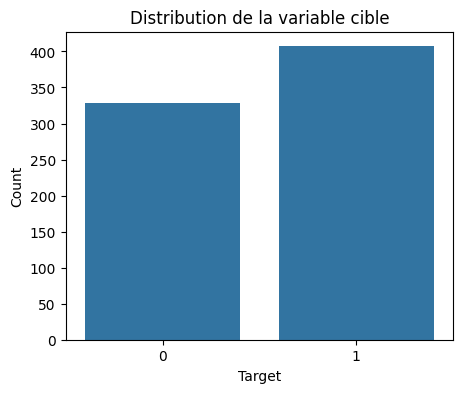

In [27]:
# ============================================================
# TARGET DISTRIBUTION
# ============================================================

plt.figure(figsize=(5, 4))
sns.countplot(x="target", data=train_df)
plt.title("Distribution de la variable cible")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

## Step 6 — Correlation of Numerical Features

Here, we explore the correlations between numerical features and the target.

### Objectives
- identify the most informative variables;
- detect potential redundancies;
- better understand the structure of the dataset.

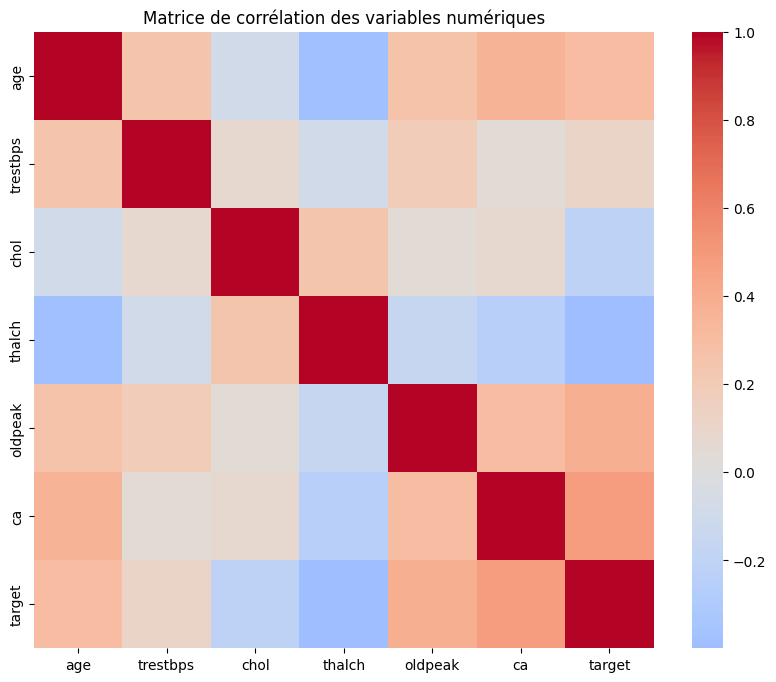

In [28]:
# ============================================================
# NUMERICAL CORRELATION
# ============================================================

numeric_preview = train_df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_preview.corr(), cmap="coolwarm", center=0)
plt.title("Matrice de corrélation des variables numériques")
plt.show()

## Step 7 — Features Most Related to the Target

Since some variables are categorical, we temporarily encode them to measure their correlation with the target.

### Important
This encoding is used only for exploration.  
Final preprocessing will be handled more properly using `ColumnTransformer` and `OneHotEncoder`.

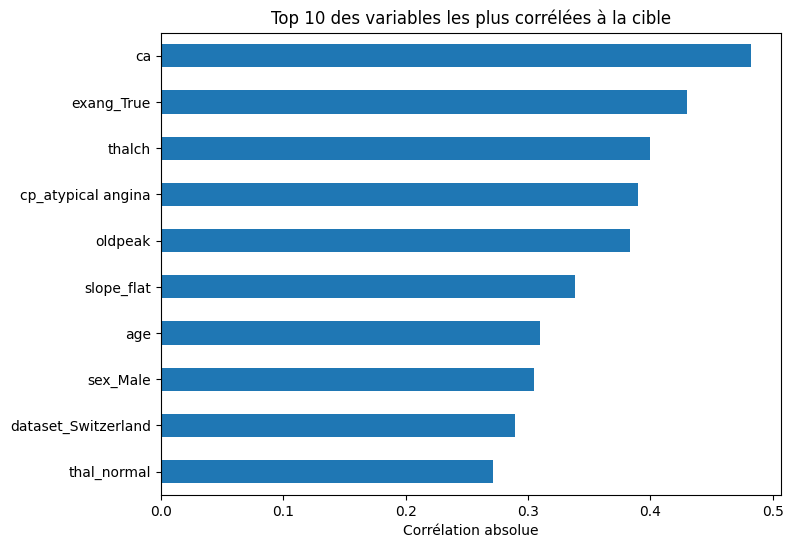

In [29]:
# ============================================================
# FEATURES MOST RELATED TO TARGET
# ============================================================

df_encoded = pd.get_dummies(train_df, drop_first=True)
corr_target = df_encoded.corr(numeric_only=True)["target"].drop("target")
top_features = corr_target.abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
top_features.sort_values().plot(kind="barh")
plt.title("Top 10 des variables les plus corrélées à la cible")
plt.xlabel("Corrélation absolue")
plt.show()

## Step 8 — Boxplots of Key Numerical Features

Here, we compare several clinical variables based on the target value.

### What these plots show
- differences in medians between groups;
- the spread of values;
- the presence of potential outliers.

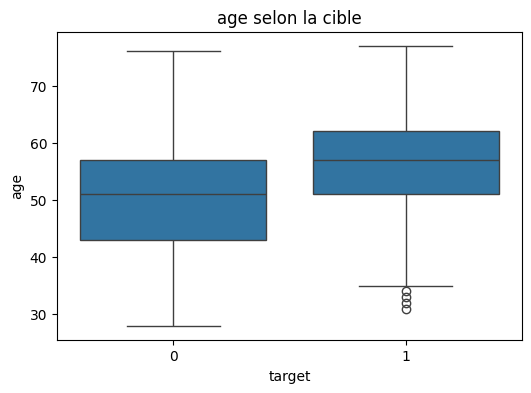

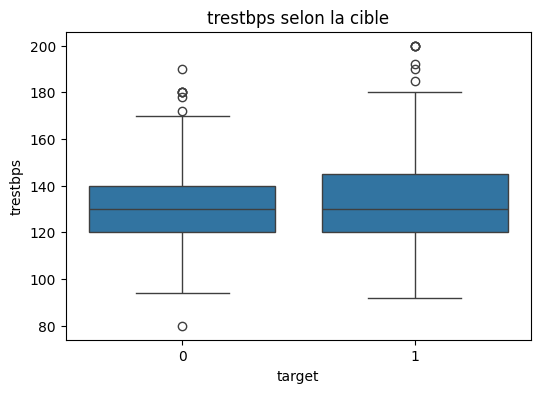

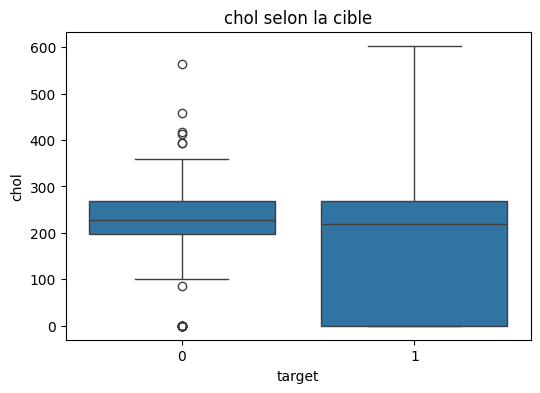

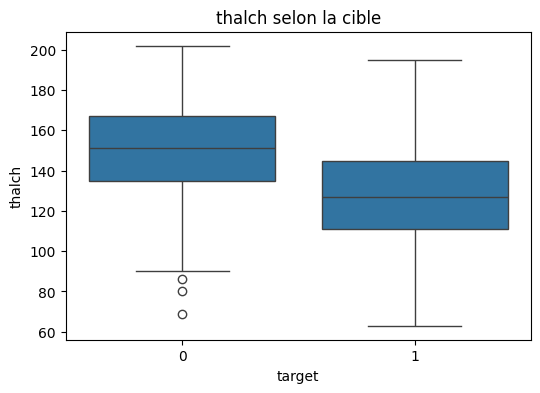

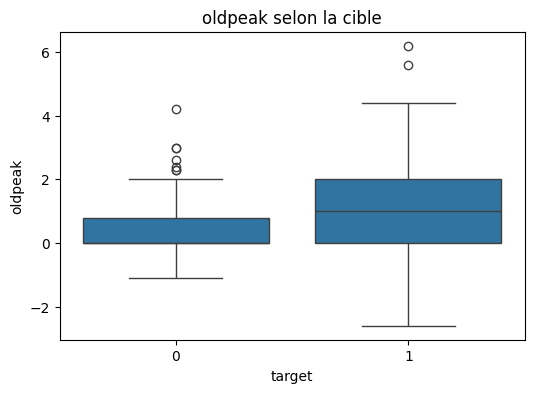

In [30]:
# ============================================================
# BOXPLOTS OF KEY NUMERICAL VARIABLES
# ============================================================

num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak"]

for col in num_cols:
    if col in train_df.columns:
        plt.figure(figsize=(6, 4))
        sns.boxplot(x="target", y=col, data=train_df)
        plt.title(f"{col} selon la cible")
        plt.show()

## Step 9 : Methodological Note — Inconsistent Zeros

Some columns contain values equal to `0` that seem medically implausible.

### Chosen approach
We replace zeros with `NaN` only in the following columns:
- `trestbps`
- `chol`
- `thalch`

### Why only these columns?
Because a zero value in these features is highly unlikely from a medical perspective.

### Why not replace all zeros?
Some columns such as `oldpeak`, `ca`, or `thal` may use `0` as a valid or informative value.  
A systematic replacement could therefore remove useful information.

In [31]:
# ============================================================
# HANDLE IMPOSSIBLE ZEROS
# ============================================================

X = X.copy()
test_df = test_df.copy()

cols_with_zero_issue = ["trestbps", "chol", "thalch"]

for col in cols_with_zero_issue:
    if col in X.columns:
        X[col] = X[col].replace(0, np.nan)
    if col in test_df.columns:
        test_df[col] = test_df[col].replace(0, np.nan)

print("Colonnes traitées pour les zéros incohérents :", cols_with_zero_issue)

Colonnes traitées pour les zéros incohérents : ['trestbps', 'chol', 'thalch']


### Step 10 : LIGHT FEATURE ENGINEERING

In [32]:
# ============================================================
# LIGHT FEATURE ENGINEERING
# ============================================================
if "age" in X.columns and "chol" in X.columns:
    X["age_chol"] = X["age"] * X["chol"]
    test_df["age_chol"] = test_df["age"] * test_df["chol"]

if "age" in X.columns and "trestbps" in X.columns:
    X["age_trestbps"] = X["age"] * X["trestbps"]
    test_df["age_trestbps"] = test_df["age"] * test_df["trestbps"]

if "thalch" in X.columns and "oldpeak" in X.columns:
    X["thalch_oldpeak"] = X["thalch"] * X["oldpeak"]
    test_df["thalch_oldpeak"] = test_df["thalch"] * test_df["oldpeak"]

print("Nouvelles variables créées :")
new_cols = [col for col in ["age_chol", "age_trestbps", "thalch_oldpeak"] if col in X.columns]
print(new_cols)

Nouvelles variables créées :
['age_chol', 'age_trestbps', 'thalch_oldpeak']


In [33]:
# ============================================================
# DEFINE NUMERICAL AND CATEGORICAL FEATURES
# ============================================================

# Choix métier : certaines colonnes codées en entier sont en réalité des catégories
numeric_features = ["age", "trestbps", "chol", "thalch", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

# On garde uniquement les colonnes réellement présentes
numeric_features = [col for col in numeric_features if col in X.columns]
categorical_features = [col for col in categorical_features if col in X.columns]

print("Variables numériques :", numeric_features)
print("Variables catégorielles :", categorical_features)

Variables numériques : ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
Variables catégorielles : ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


### Step 11 : PREPROCESSING PIPELINES

In [34]:
# ============================================================
# PREPROCESSING PIPELINES
# ============================================================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

### Step 12 : FULL LIGHTGBM PIPELINE
Le pipeline nous permet d’éviter toute fuite logique et garantit que le même traitement est appliqué de manière rigoureuse à toutes les étapes.

In [35]:
# ============================================================
#  FULL LIGHTGBM PIPELINE
# ============================================================
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LGBMClassifier(
        objective="binary",
        random_state=RANDOM_STATE,
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31
    ))
])

pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalch', 'oldpeak']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'cp', 'fbs',
                                                   'restecg', 'exang', 'slope',
                                                   'ca', 'thal'])])),
                ('model',
                 LGBMClassifier(learning_rate=0.05, n_estimators=300,
                                objective='binary', random_state=42))])

### Step 13 : TRAIN / VALIDATION SPLIT.


In [36]:
# ============================================================
# TRAIN / VALIDATION SPLIT
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train shape :", X_train.shape, y_train.shape)
print("Validation shape :", X_val.shape, y_val.shape)

Train shape : (588, 17) (588,)
Validation shape : (148, 17) (148,)


### Step 14 : HYPERPARAMETER TUNING WITH GRIDSEARCH

In [37]:
# ============================================================
#  HYPERPARAMETER TUNING WITH GRIDSEARCH
# ============================================================
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [200, 300],
    "model__learning_rate": [0.05, 0.1],
    "model__num_leaves": [31, 63],
    "model__max_depth": [-1, 10]
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best parameters :", grid.best_params_)
print("Best CV score :", grid.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[LightGBM] [Info] Number of positive: 260, number of negative: 210
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.117350 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 325
[LightGBM] [Info] Number of data points in the train set: 470, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.553191 -> initscore=0.213574
[LightGBM] [Info] Start training from score 0.213574
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [War

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 260, number of negative: 210
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.120809 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 322
[LightGBM] [Info] Number of data points in the train set: 470, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.553191 -> initscore=0.213574
[LightGBM] [Info] Start training from score 0.213574
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Step 15 : VALIDATION PREDICTIONS

In [38]:
# ============================================================
# VALIDATION PREDICTIONS
# ============================================================

best_model = grid.best_estimator_

# Probabilités pour la classe positive
val_proba = best_model.predict_proba(X_val)[:, 1]

# Prédiction par défaut au seuil 0.5
val_pred_default = (val_proba >= 0.5).astype(int)

print("F1 macro au seuil 0.5 :", round(f1_score(y_val, val_pred_default, average="macro"), 4))
print("\nClassification report (threshold=0.5) :\n")
print(classification_report(y_val, val_pred_default))
print("Confusion matrix :")
print(confusion_matrix(y_val, val_pred_default))

F1 macro au seuil 0.5 : 0.8008

Classification report (threshold=0.5) :

              precision    recall  f1-score   support

           0       0.79      0.76      0.78        66
           1       0.81      0.84      0.83        82

    accuracy                           0.80       148
   macro avg       0.80      0.80      0.80       148
weighted avg       0.80      0.80      0.80       148

Confusion matrix :
[[50 16]
 [13 69]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Step 16 : THRESHOLD TUNING

In [39]:
# ============================================================
# THRESHOLD TUNING
# ============================================================
thresholds = np.arange(0.10, 0.90, 0.01)
scores = []

for t in thresholds:
    preds = (val_proba >= t).astype(int)
    score = f1_score(y_val, preds, average="macro")
    scores.append(score)

best_idx = np.argmax(scores)
best_threshold = thresholds[best_idx]
best_f1 = scores[best_idx]

print("Best threshold :", round(best_threshold, 2))
print("Best F1 macro on validation :", round(best_f1, 4))

Best threshold : 0.62
Best F1 macro on validation : 0.8157


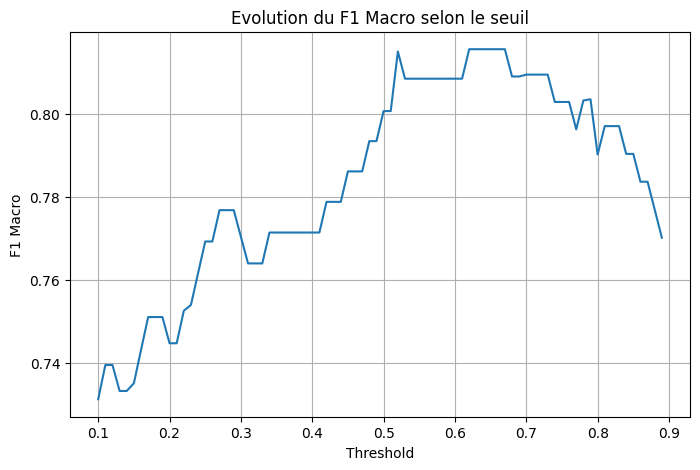

In [40]:
# ============================================================
# THRESHOLD CURVE
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(thresholds, scores)
plt.xlabel("Threshold")
plt.ylabel("F1 Macro")
plt.title("Evolution du F1 Macro selon le seuil")
plt.grid(True)
plt.show()

### Step 17 : FINAL VALIDATION EVALUATION WITH BEST THRESHOLD


In [41]:
# ============================================================
# FINAL VALIDATION EVALUATION WITH BEST THRESHOLD
# ============================================================

y_val_pred = (val_proba >= best_threshold).astype(int)

print("Validation F1-macro (best threshold) :", round(f1_score(y_val, y_val_pred, average="macro"), 4))
print("\nClassification report :\n")
print(classification_report(y_val, y_val_pred))
print("Confusion matrix :")
print(confusion_matrix(y_val, y_val_pred))

Validation F1-macro (best threshold) : 0.8157

Classification report :

              precision    recall  f1-score   support

           0       0.79      0.80      0.80        66
           1       0.84      0.83      0.83        82

    accuracy                           0.82       148
   macro avg       0.82      0.82      0.82       148
weighted avg       0.82      0.82      0.82       148

Confusion matrix :
[[53 13]
 [14 68]]


### Step 18 : FINAL TRAINING ON FULL DATA


In [42]:
# ============================================================
# FINAL TRAINING ON FULL DATA
# ============================================================

final_model = grid.best_estimator_
final_model.fit(X, y)

[LightGBM] [Info] Number of positive: 407, number of negative: 329
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000271 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 391
[LightGBM] [Info] Number of data points in the train set: 736, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.552989 -> initscore=0.212755
[LightGBM] [Info] Start training from score 0.212755
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalch', 'oldpeak']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'cp', 'fbs',
                                                   'restecg', 'exang', 'slope',
                                                   'ca', 'thal'])])),
                ('model',
                 LGBMClassifier(max_depth=10, n_estimators=200,
                                objective='binary', random_state=42))])

### Step 19 : TEST PREDICTION AND SUBMISSION


In [43]:
# ============================================================
# TEST PREDICTION AND SUBMISSION
# ============================================================

test_proba = final_model.predict_proba(test_df)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)

submission = sample_df.copy()
submission["target"] = test_pred

submission.to_csv("submission.csv", index=False)

print("File submission created.")
display(submission.head())

File submission created.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,id,target
0,515,1
1,826,1
2,855,1
3,805,1
4,888,0


### Step 20 : FEATURE IMPORTANCE

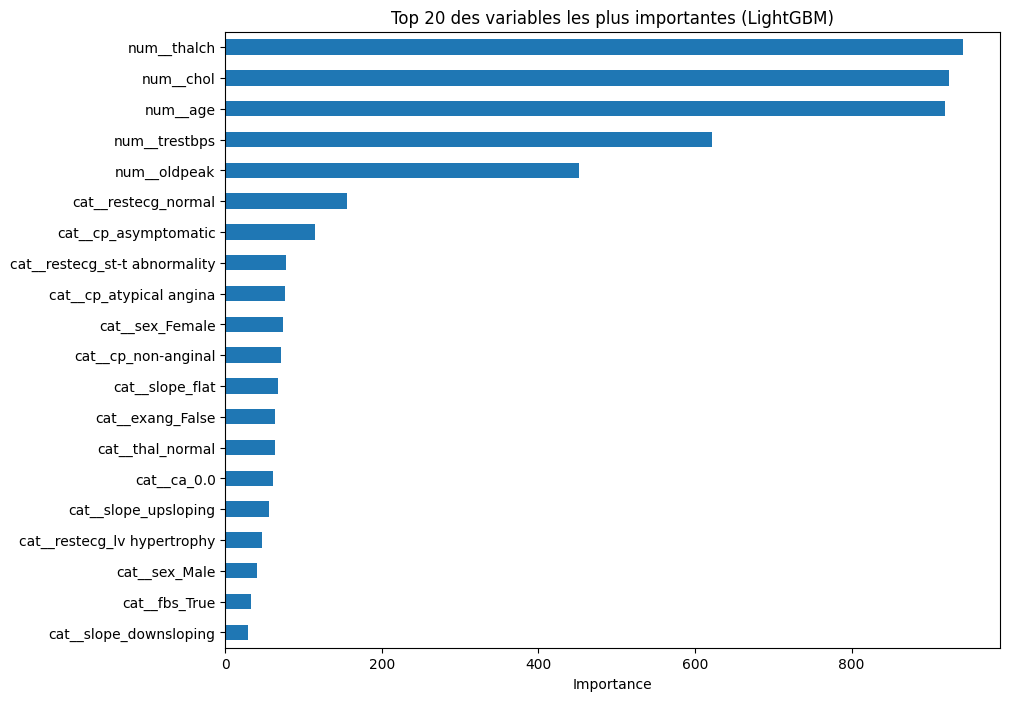

Top 20 features :


num__thalch                      943
num__chol                        924
num__age                         919
num__trestbps                    622
num__oldpeak                     452
cat__restecg_normal              155
cat__cp_asymptomatic             114
cat__restecg_st-t abnormality     77
cat__cp_atypical angina           76
cat__sex_Female                   74
cat__cp_non-anginal               71
cat__slope_flat                   67
cat__exang_False                  64
cat__thal_normal                  63
cat__ca_0.0                       61
cat__slope_upsloping              56
cat__restecg_lv hypertrophy       47
cat__sex_Male                     40
cat__fbs_True                     33
cat__slope_downsloping            29
dtype: int32

In [44]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================
preprocessor_fitted = final_model.named_steps["preprocessor"]
lgbm_model = final_model.named_steps["model"]

feature_names = preprocessor_fitted.get_feature_names_out()
importances = pd.Series(lgbm_model.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 des variables les plus importantes (LightGBM)")
plt.xlabel("Importance")
plt.show()

print("Top 20 features :")
display(importances.head(20))